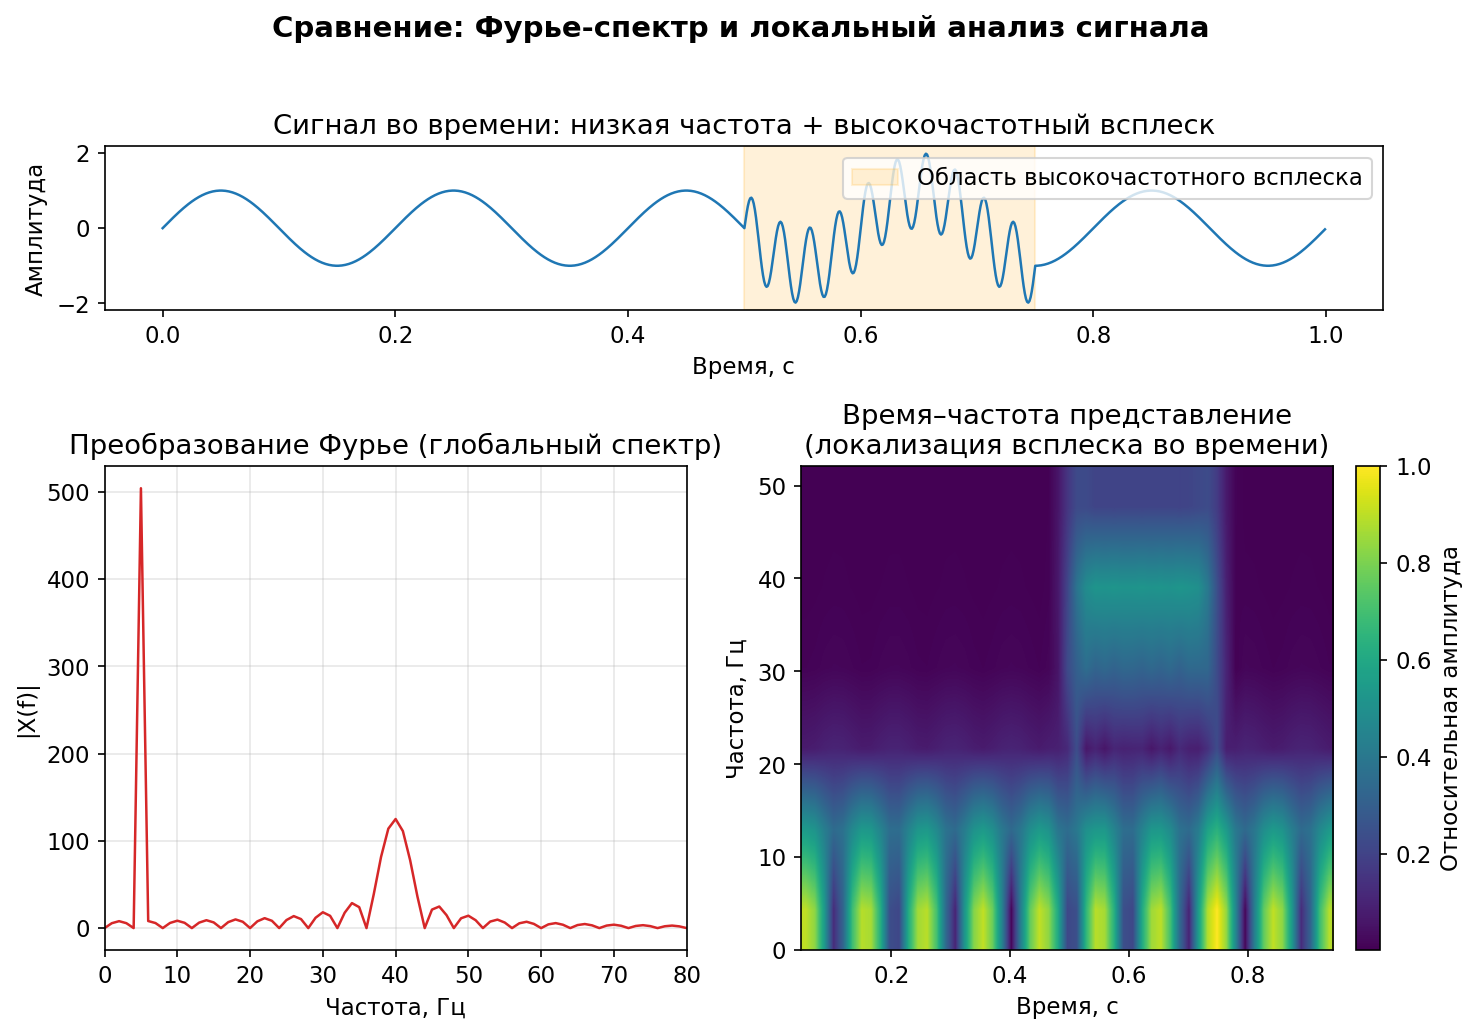

In [5]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 150
plt.rcParams["font.size"] = 11

# ---------- 1. Генерация сигнала ----------
fs = 1000  # частота дискретизации, Гц
T = 1.0    # длительность, с
t = np.linspace(0, T, int(fs*T), endpoint=False)

x_low = np.sin(2 * np.pi * 5 * t)  # низкая частота
burst = (t > 0.5) & (t < 0.75)     # окно для всплеска
x_high = np.sin(2 * np.pi * 40 * t) * burst  # высокочастотный всплеск
x = x_low + x_high

# ---------- 2. Глобальный Фурье-спектр ----------
X = np.fft.rfft(x)
freqs_full = np.fft.rfftfreq(len(t), 1/fs)
X_mag = np.abs(X)

# ---------- 3. Время–частота карта ----------
win_size = 96      # было 128 — чуть меньше окно
step = 16          # было 32 — чаще берем окна
windows = []
spec_tf = []

start_idx = 0
while start_idx + win_size <= len(x):
    segment = x[start_idx:start_idx + win_size]
    w = np.hanning(win_size)
    seg_win = segment * w
    seg_X = np.fft.rfft(seg_win)
    windows.append(t[start_idx + win_size//2])
    spec_tf.append(np.abs(seg_X))
    start_idx += step

spec_tf = np.array(spec_tf)
freqs_win = np.fft.rfftfreq(win_size, 1/fs)

# ограничим частоты до 60 Гц
freq_mask = freqs_win <= 60
freqs_vis = freqs_win[freq_mask]
spec_tf_vis = spec_tf[:, freq_mask]

# нормировка
spec_tf_vis = spec_tf_vis / (spec_tf_vis.max() + 1e-12)

# ---------- 4. Рисунок ----------
fig = plt.figure(figsize=(10, 7))

# a) сигнал
ax1 = plt.subplot2grid((3, 2), (0, 0), colspan=2)
ax1.plot(t, x, color="#1f77b4", lw=1.2)
ax1.set_title("Сигнал во времени: низкая частота + высокочастотный всплеск")
ax1.set_xlabel("Время, с")
ax1.set_ylabel("Амплитуда")
ax1.axvspan(0.5, 0.75, color="orange", alpha=0.15,
            label="Область высокочастотного всплеска")
ax1.legend(loc="upper right")

# b) глобальный Фурье
ax2 = plt.subplot2grid((3, 2), (1, 0), rowspan=2)
ax2.plot(freqs_full, X_mag, color="#d62728", lw=1.2)
ax2.set_xlim(0, 80)
ax2.set_title("Преобразование Фурье (глобальный спектр)")
ax2.set_xlabel("Частота, Гц")
ax2.set_ylabel("|X(f)|")
ax2.grid(alpha=0.3)

# c) время–частота карта
ax3 = plt.subplot2grid((3, 2), (1, 1), rowspan=2)
im = ax3.imshow(
    spec_tf_vis.T,
    origin="lower",
    aspect="auto",
    extent=[windows[0], windows[-1], freqs_vis[0], freqs_vis[-1]],
    cmap="viridis",
    interpolation="bilinear"  # сглаживание "пикселей"
)
ax3.set_title("Время–частота представление\n(локализация всплеска во времени)")
ax3.set_xlabel("Время, с")
ax3.set_ylabel("Частота, Гц")

cbar = plt.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)
cbar.set_label("Относительная амплитуда")

fig.suptitle("Сравнение: Фурье-спектр и локальный анализ сигнала",
             fontsize=14, weight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

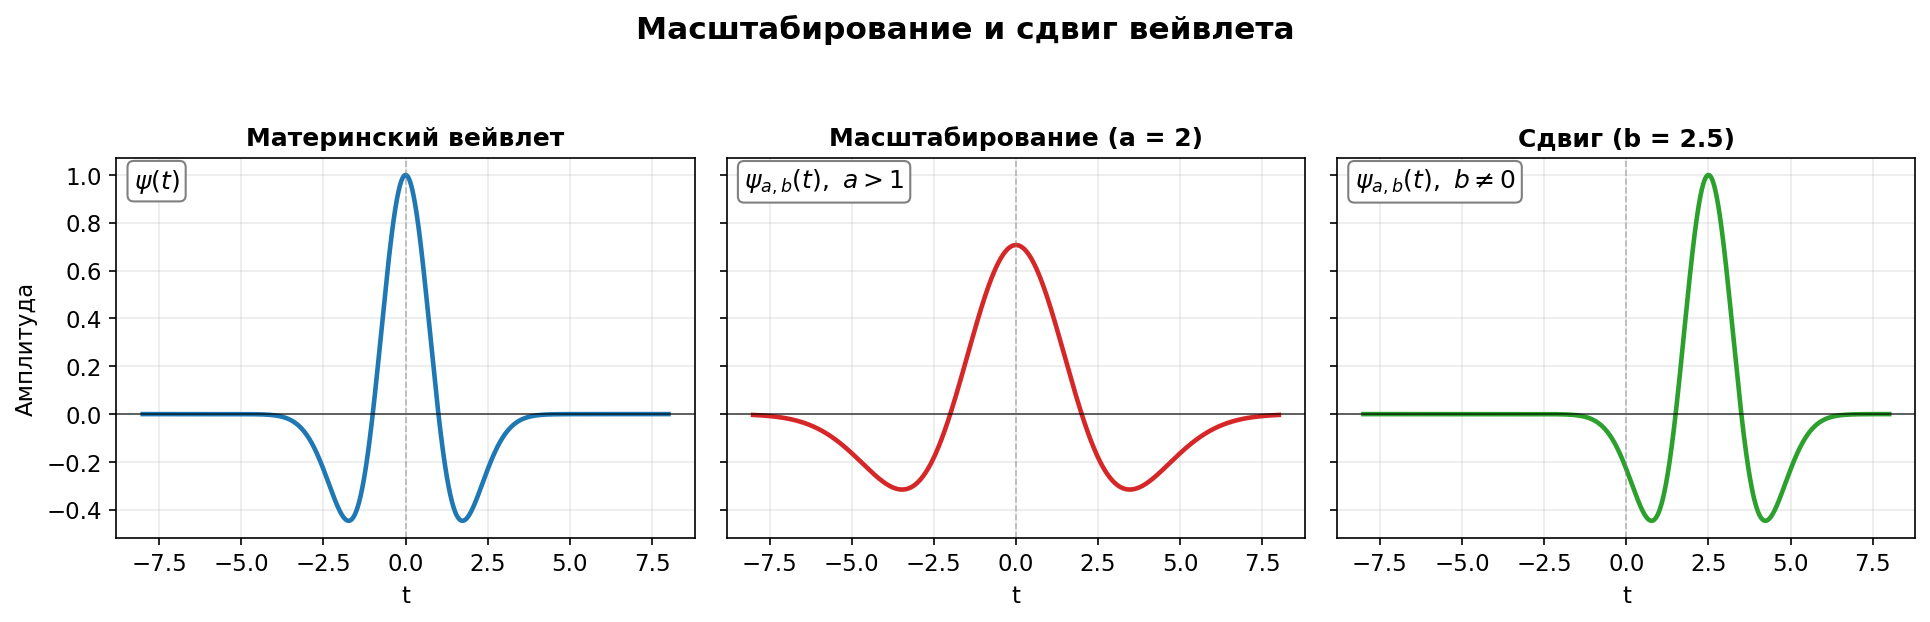

In [6]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 150
plt.rcParams["font.size"] = 11

# --------- Материнский вейвлет (Mexican Hat / Ricker-like) ----------
def psi(t):
    return (1 - t**2) * np.exp(-t**2 / 2)

# Формула дочернего вейвлета
def psi_ab(t, a, b):
    return (1 / np.sqrt(abs(a))) * psi((t - b) / a)

# Ось времени
t = np.linspace(-8, 8, 2000)

# Варианты
y0 = psi_ab(t, a=1.0, b=0.0)   # материнский
y1 = psi_ab(t, a=2.0, b=0.0)   # растянутый
y2 = psi_ab(t, a=1.0, b=2.5)   # сдвинутый

# --------- Построение ----------
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)

titles = [
    "Материнский вейвлет",
    "Масштабирование (a = 2)",
    "Сдвиг (b = 2.5)"
]
curves = [y0, y1, y2]
colors = ["#1f77b4", "#d62728", "#2ca02c"]

for ax, y, title, color in zip(axes, curves, titles, colors):
    ax.plot(t, y, color=color, lw=2.2)
    ax.axhline(0, color="black", lw=0.8, alpha=0.7)
    ax.axvline(0, color="gray", lw=0.8, alpha=0.5, linestyle="--")
    ax.set_title(title, fontsize=12, weight="bold")
    ax.set_xlabel("t")
    ax.grid(alpha=0.25)

axes[0].set_ylabel("Амплитуда")
axes[0].text(0.03, 0.92, r"$\psi(t)$", transform=axes[0].transAxes,
             fontsize=12, bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="gray"))
axes[1].text(0.03, 0.92, r"$\psi_{a,b}(t),\ a>1$", transform=axes[1].transAxes,
             fontsize=12, bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="gray"))
axes[2].text(0.03, 0.92, r"$\psi_{a,b}(t),\ b\neq0$", transform=axes[2].transAxes,
             fontsize=12, bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="gray"))

fig.suptitle("Масштабирование и сдвиг вейвлета", fontsize=15, weight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.93])

plt.show()

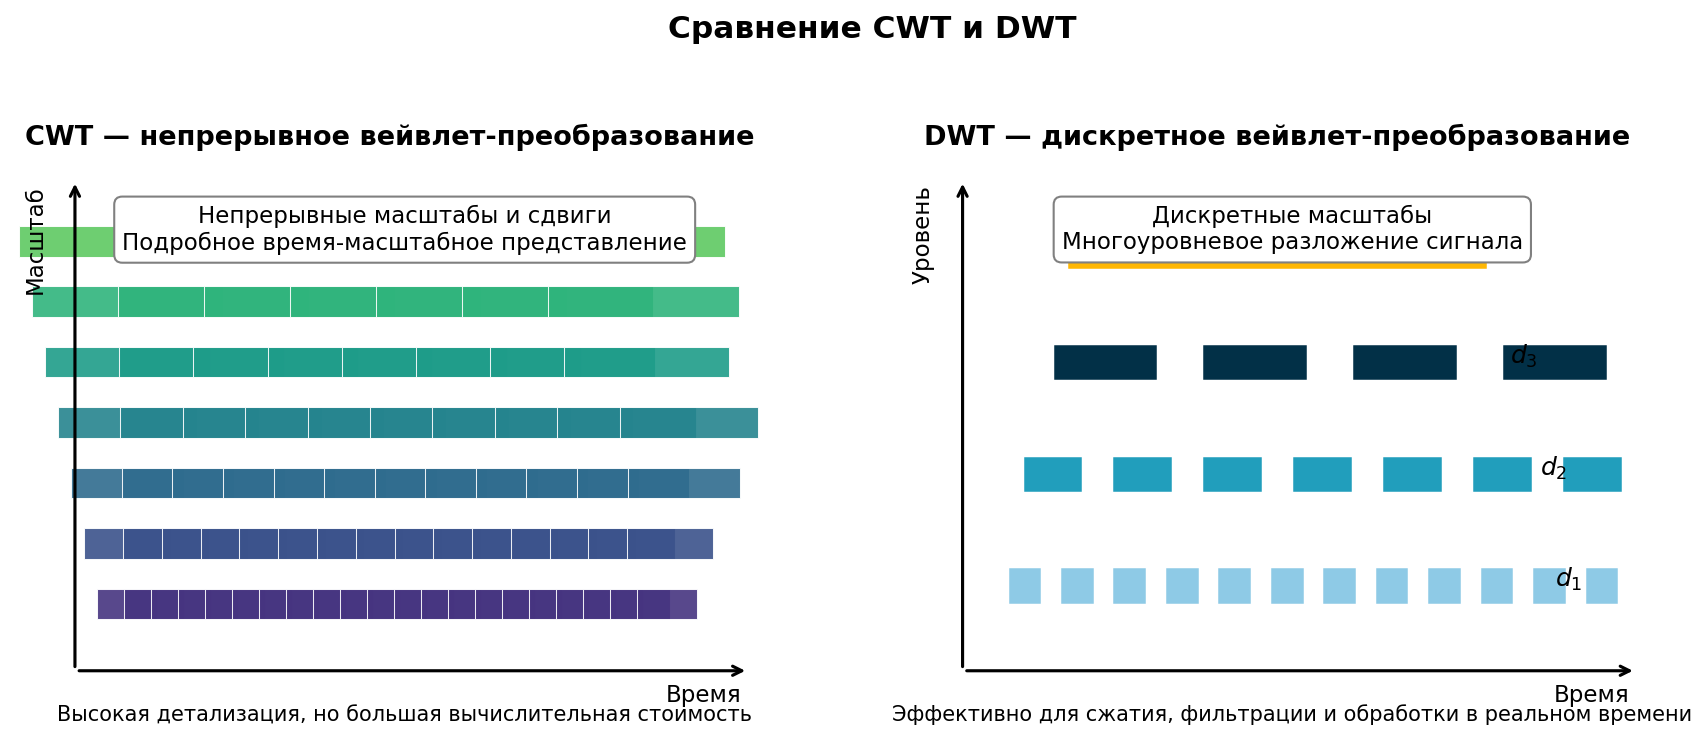

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

plt.rcParams["figure.dpi"] = 150
plt.rcParams["font.size"] = 11

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -------------------- CWT --------------------
ax = axes[0]
ax.set_title("CWT — непрерывное вейвлет-преобразование", fontsize=13, weight="bold")
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)

# Оси
ax.annotate("", xy=(9.8, 0.8), xytext=(0.8, 0.8),
            arrowprops=dict(arrowstyle="->", lw=1.5, color="black"))
ax.annotate("", xy=(0.8, 9.6), xytext=(0.8, 0.8),
            arrowprops=dict(arrowstyle="->", lw=1.5, color="black"))

ax.text(9.7, 0.25, "Время", ha="right")
ax.text(0.12, 9.5, "Масштаб", rotation=90, va="top")

# Плотное покрытие окнами разного размера
levels = np.linspace(2, 8.5, 7)
for i, y in enumerate(levels):
    width = 0.8 + 0.35 * i
    xs = np.arange(1.5, 9.0, width * 0.45)
    for x in xs:
        rect = Rectangle((x - width/2, y - 0.28), width, 0.55,
                         facecolor=plt.cm.viridis(0.15 + 0.1 * i),
                         edgecolor="white", lw=0.5, alpha=0.9)
        ax.add_patch(rect)

ax.text(5.2, 9.15,
        "Непрерывные масштабы и сдвиги\nПодробное время-масштабное представление",
        ha="center", va="top",
        bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="gray"))

ax.text(5.2, -0.1,
        "Высокая детализация, но большая вычислительная стоимость",
        ha="center", fontsize=10)

ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

# -------------------- DWT --------------------
ax = axes[1]
ax.set_title("DWT — дискретное вейвлет-преобразование", fontsize=13, weight="bold")
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)

# Оси
ax.annotate("", xy=(9.8, 0.8), xytext=(0.8, 0.8),
            arrowprops=dict(arrowstyle="->", lw=1.5, color="black"))
ax.annotate("", xy=(0.8, 9.6), xytext=(0.8, 0.8),
            arrowprops=dict(arrowstyle="->", lw=1.5, color="black"))

ax.text(9.7, 0.25, "Время", ha="right")
ax.text(0.12, 9.5, "Уровень", rotation=90, va="top")

# Дискретные уровни разложения
# d1
for x in np.arange(1.4, 9.2, 0.7):
    ax.add_patch(Rectangle((x, 2.0), 0.45, 0.65,
                           facecolor="#8ecae6", edgecolor="white", lw=0.7))
# d2
for x in np.arange(1.6, 9.0, 1.2):
    ax.add_patch(Rectangle((x, 4.0), 0.8, 0.65,
                           facecolor="#219ebc", edgecolor="white", lw=0.7))
# d3
for x in np.arange(2.0, 8.5, 2.0):
    ax.add_patch(Rectangle((x, 6.0), 1.4, 0.65,
                           facecolor="#023047", edgecolor="white", lw=0.7))
# a3
ax.add_patch(Rectangle((2.2, 8.0), 5.6, 0.75,
                       facecolor="#ffb703", edgecolor="white", lw=0.7))

# Подписи уровней
ax.text(8.7, 2.3, r"$d_1$", fontsize=12, weight="bold")
ax.text(8.5, 4.3, r"$d_2$", fontsize=12, weight="bold")
ax.text(8.1, 6.3, r"$d_3$", fontsize=12, weight="bold")
ax.text(8.0, 8.35, r"$a_3$", fontsize=12, weight="bold")

ax.text(5.2, 9.15,
        "Дискретные масштабы\nМногоуровневое разложение сигнала",
        ha="center", va="top",
        bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="gray"))

ax.text(5.2, -0.1,
        "Эффективно для сжатия, фильтрации и обработки в реальном времени",
        ha="center", fontsize=10)

ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

fig.suptitle("Сравнение CWT и DWT", fontsize=15, weight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

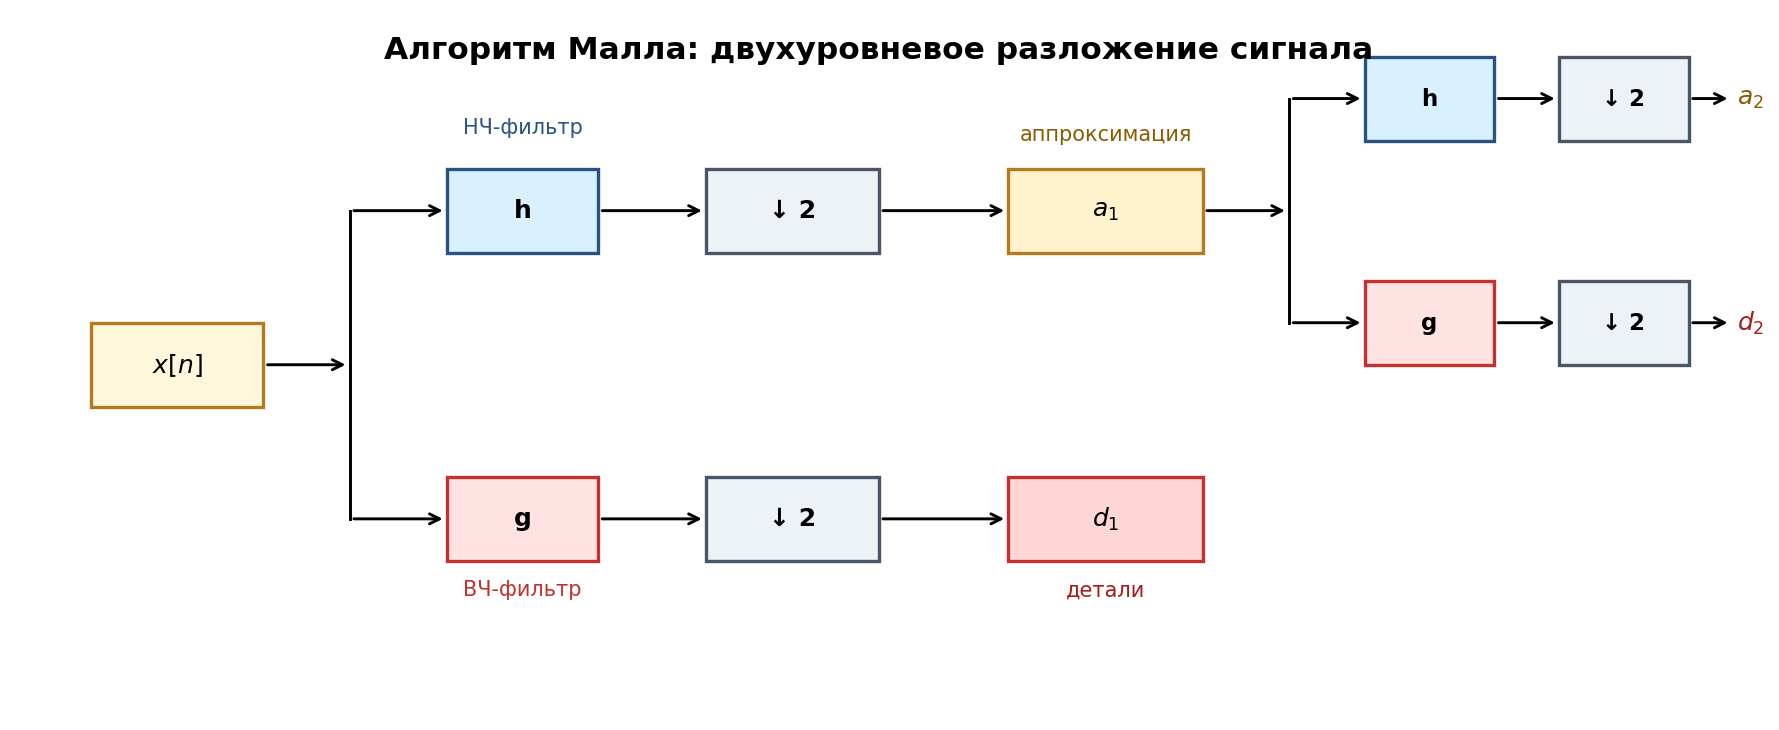

In [8]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch

plt.rcParams["figure.dpi"] = 150
plt.rcParams["font.size"] = 11

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_xlim(0, 16)
ax.set_ylim(0, 10)
ax.axis("off")

def box(x, y, w, h, text, fc="#e9f2ff", ec="#2b6cb0", fontsize=11, weight="normal"):
    rect = Rectangle((x, y), w, h, facecolor=fc, edgecolor=ec, linewidth=1.6)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha="center", va="center",
            fontsize=fontsize, weight=weight)
    return rect

def arrow(x1, y1, x2, y2, color="black", lw=1.4):
    arr = FancyArrowPatch((x1, y1), (x2, y2),
                          arrowstyle="->", mutation_scale=12,
                          linewidth=lw, color=color)
    ax.add_patch(arr)

# ---------- Вход ----------
box(0.7, 4.4, 1.6, 1.2, r"$x[n]$", fc="#fff7db", ec="#b7791f", fontsize=12, weight="bold")

# Разветвление
arrow(2.3, 5.0, 3.1, 5.0)
ax.plot([3.1, 3.1], [5.0, 7.2], color="black", lw=1.4)
ax.plot([3.1, 3.1], [5.0, 2.8], color="black", lw=1.4)

# ---------- Верхняя ветка: h -> ↓2 -> a1 ----------
arrow(3.1, 7.2, 4.0, 7.2)
box(4.0, 6.6, 1.4, 1.2, "h", fc="#d9f0ff", ec="#2c5282", fontsize=12, weight="bold")
arrow(5.4, 7.2, 6.4, 7.2)
box(6.4, 6.6, 1.6, 1.2, "↓ 2", fc="#edf2f7", ec="#4a5568", fontsize=12, weight="bold")
arrow(8.0, 7.2, 9.2, 7.2)
box(9.2, 6.6, 1.8, 1.2, r"$a_1$", fc="#fff2cc", ec="#b7791f", fontsize=12, weight="bold")

# ---------- Нижняя ветка: g -> ↓2 -> d1 ----------
arrow(3.1, 2.8, 4.0, 2.8)
box(4.0, 2.2, 1.4, 1.2, "g", fc="#ffe3e3", ec="#c53030", fontsize=12, weight="bold")
arrow(5.4, 2.8, 6.4, 2.8)
box(6.4, 2.2, 1.6, 1.2, "↓ 2", fc="#edf2f7", ec="#4a5568", fontsize=12, weight="bold")
arrow(8.0, 2.8, 9.2, 2.8)
box(9.2, 2.2, 1.8, 1.2, r"$d_1$", fc="#ffd6d6", ec="#c53030", fontsize=12, weight="bold")

# ---------- Второй уровень от a1 ----------
arrow(11.0, 7.2, 11.8, 7.2)
ax.plot([11.8, 11.8], [7.2, 8.8], color="black", lw=1.4)
ax.plot([11.8, 11.8], [7.2, 5.6], color="black", lw=1.4)

# Верхняя ветка 2-го уровня
arrow(11.8, 8.8, 12.5, 8.8)
box(12.5, 8.2, 1.2, 1.2, "h", fc="#d9f0ff", ec="#2c5282", fontsize=11, weight="bold")
arrow(13.7, 8.8, 14.3, 8.8)
box(14.3, 8.2, 1.2, 1.2, "↓ 2", fc="#edf2f7", ec="#4a5568", fontsize=11, weight="bold")
arrow(15.5, 8.8, 15.9, 8.8)
ax.text(15.95, 8.8, r"$a_2$", va="center", ha="left", fontsize=12, weight="bold", color="#8c5a00")

# Нижняя ветка 2-го уровня
arrow(11.8, 5.6, 12.5, 5.6)
box(12.5, 5.0, 1.2, 1.2, "g", fc="#ffe3e3", ec="#c53030", fontsize=11, weight="bold")
arrow(13.7, 5.6, 14.3, 5.6)
box(14.3, 5.0, 1.2, 1.2, "↓ 2", fc="#edf2f7", ec="#4a5568", fontsize=11, weight="bold")
arrow(15.5, 5.6, 15.9, 5.6)
ax.text(15.95, 5.6, r"$d_2$", va="center", ha="left", fontsize=12, weight="bold", color="#a61b1b")

# ---------- Подписи ----------
ax.text(8.0, 9.5, "Алгоритм Малла: двухуровневое разложение сигнала", 
        ha="center", va="center", fontsize=15, weight="bold")

ax.text(4.7, 8.3, "НЧ-фильтр", ha="center", fontsize=10, color="#2c5282")
ax.text(4.7, 1.7, "ВЧ-фильтр", ha="center", fontsize=10, color="#c53030")
ax.text(10.1, 8.2, "аппроксимация", ha="center", fontsize=10, color="#8c5a00")
ax.text(10.1, 1.7, "детали", ha="center", fontsize=10, color="#a61b1b")

plt.tight_layout()
plt.show()

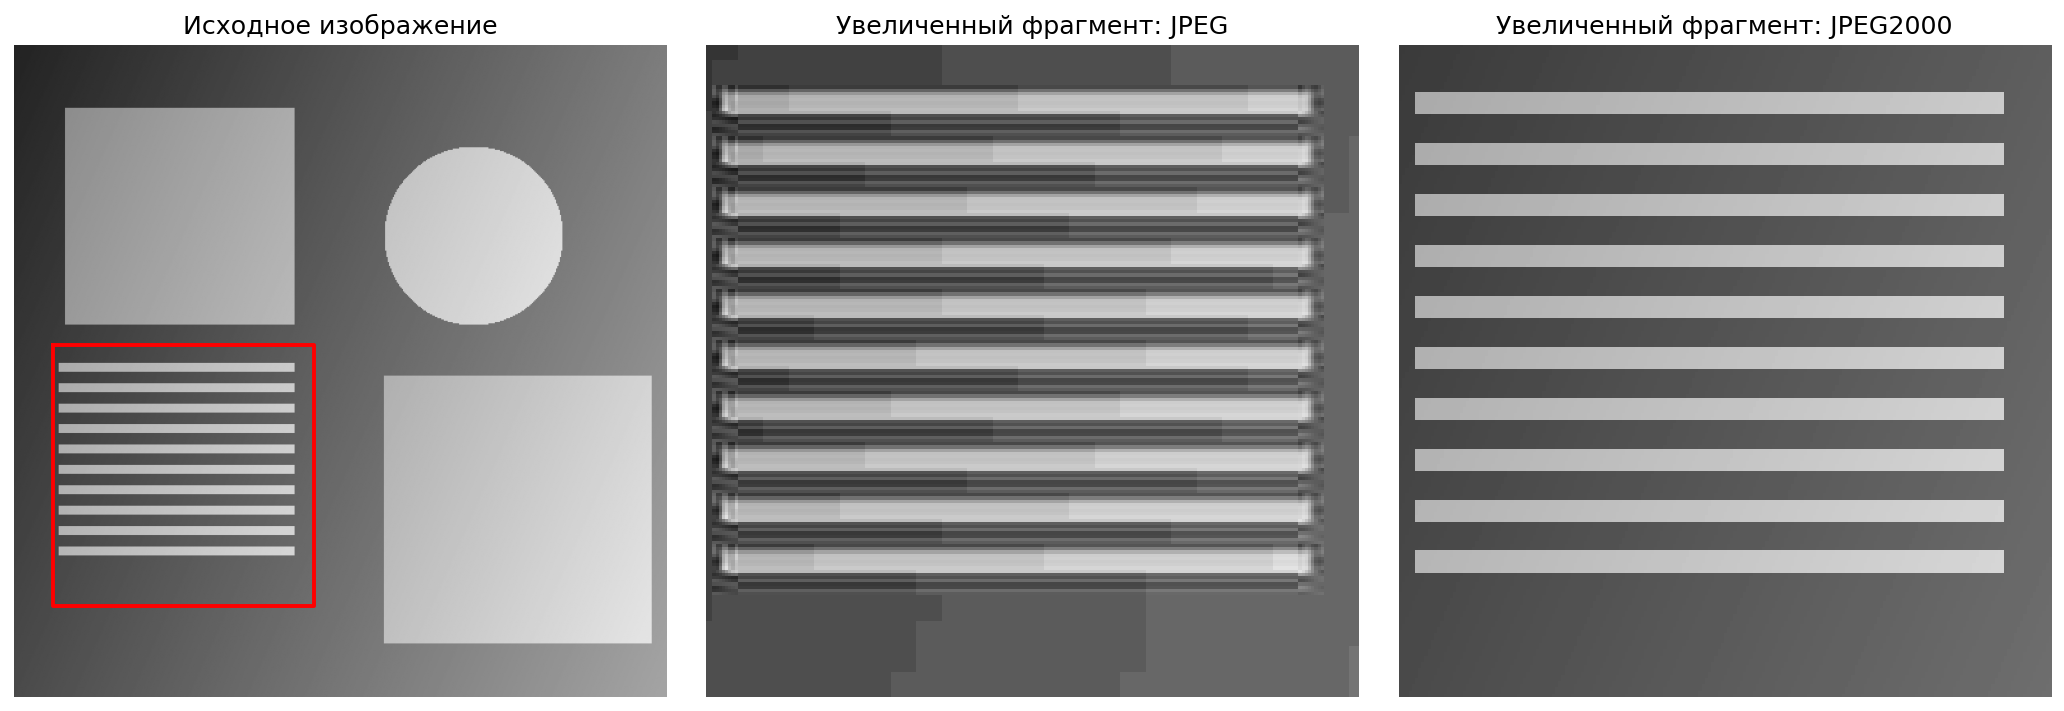

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, features

# -------------------------------------------------
# 1) Исходное изображение
# -------------------------------------------------
h, w = 512, 512
Y, X = np.mgrid[0:h, 0:w]

img = np.zeros((h, w), dtype=np.float32)
img += 35 + 90 * (X / w) + 40 * (Y / h)

img[50:220, 40:220] += 95
img[260:470, 290:500] += 70

circle = (X - 360) ** 2 + (Y - 150) ** 2
img[circle < 70**2] += 100

for i in range(10):
    y0 = 250 + i * 16
    img[y0:y0+7, 35:220] += 110

img = np.clip(img, 0, 255).astype(np.uint8)
orig = Image.fromarray(img).convert("L")

# -------------------------------------------------
# 2) Сохраняем JPEG
# -------------------------------------------------
orig.save("demo_jpeg.jpg", quality=8, subsampling=2)
jpeg_img = Image.open("demo_jpeg.jpg").convert("L")

# -------------------------------------------------
# 3) Сохраняем JPEG2000
# -------------------------------------------------
if not features.check_codec("jpg_2000"):
    raise RuntimeError(
        "В Pillow нет поддержки JPEG2000. "
        "Нужен Pillow с OpenJPEG."
    )

orig.save("demo_jpeg2000.jp2", format="JPEG2000")
jpeg2000_img = Image.open("demo_jpeg2000.jp2").convert("L")

# -------------------------------------------------
# 4) Выбираем одинаковый фрагмент для увеличения
# -------------------------------------------------
crop = (30, 235, 235, 440)  # left, top, right, bottom

jpeg_crop = jpeg_img.crop(crop)
jpeg2000_crop = jpeg2000_img.crop(crop)

# -------------------------------------------------
# 5) Показываем исходное и увеличенные фрагменты
# -------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=140)

axes[0].imshow(np.array(orig), cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Исходное изображение", fontsize=13)
axes[0].axis("off")

# рамка области увеличения на исходном
rect_x = [crop[0], crop[2], crop[2], crop[0], crop[0]]
rect_y = [crop[1], crop[1], crop[3], crop[3], crop[1]]
axes[0].plot(rect_x, rect_y, color="red", linewidth=2)

axes[1].imshow(np.array(jpeg_crop), cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Увеличенный фрагмент: JPEG", fontsize=13)
axes[1].axis("off")

axes[2].imshow(np.array(jpeg2000_crop), cmap="gray", vmin=0, vmax=255)
axes[2].set_title("Увеличенный фрагмент: JPEG2000", fontsize=13)
axes[2].axis("off")

plt.tight_layout()
plt.show()

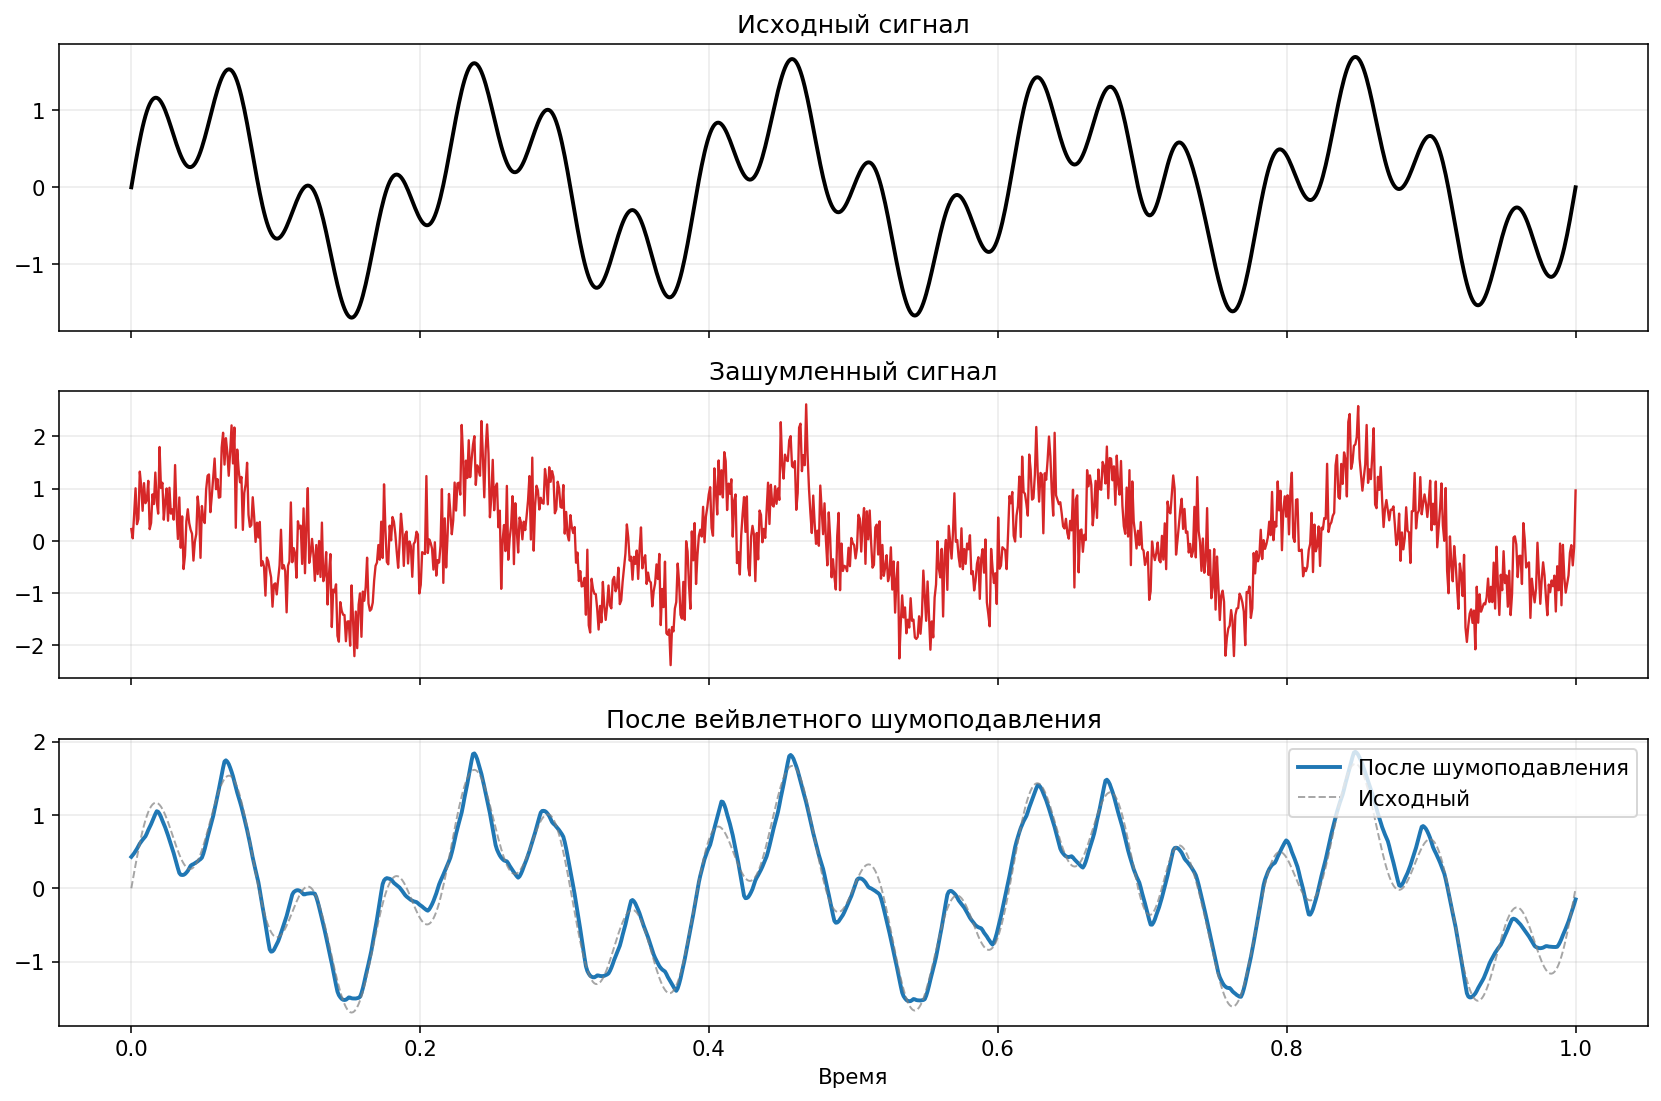

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

# ----------------------------
# 1. Исходный сигнал
# ----------------------------
np.random.seed(42)
t = np.linspace(0, 1, 1024)

clean = (
    np.sin(2 * np.pi * 5 * t)
    + 0.7 * np.sin(2 * np.pi * 18 * t)
)

# добавим локальный импульс
clean += 1.2 * np.exp(-((t - 0.72) / 0.015) ** 2)

# ----------------------------
# 2. Шум
# ----------------------------
noise = 0.45 * np.random.randn(len(t))
noisy = clean + noise

# ----------------------------
# 3. Вейвлетное шумоподавление
# ----------------------------
wavelet = 'sym4'
level = 4

coeffs = pywt.wavedec(noisy, wavelet, level=level)

# оценка шума по детализирующим коэффициентам высокого уровня
sigma = np.median(np.abs(coeffs[-1])) / 0.6745
threshold = sigma * np.sqrt(2 * np.log(len(noisy)))

# мягкая пороговая обработка
coeffs_thresh = [coeffs[0]]
for c in coeffs[1:]:
    coeffs_thresh.append(pywt.threshold(c, threshold, mode='soft'))

denoised = pywt.waverec(coeffs_thresh, wavelet)
denoised = denoised[:len(t)]

# ----------------------------
# 4. Визуализация
# ----------------------------
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True, dpi=140)

axes[0].plot(t, clean, color='black', linewidth=2)
axes[0].set_title("Исходный сигнал", fontsize=13)
axes[0].grid(alpha=0.25)

axes[1].plot(t, noisy, color='tab:red', linewidth=1.2)
axes[1].set_title("Зашумленный сигнал", fontsize=13)
axes[1].grid(alpha=0.25)

axes[2].plot(t, denoised, color='tab:blue', linewidth=2, label='После шумоподавления')
axes[2].plot(t, clean, color='gray', linewidth=1, alpha=0.7, linestyle='--', label='Исходный')
axes[2].set_title("После вейвлетного шумоподавления", fontsize=13)
axes[2].grid(alpha=0.25)
axes[2].legend()

plt.xlabel("Время")
plt.tight_layout()
plt.show()

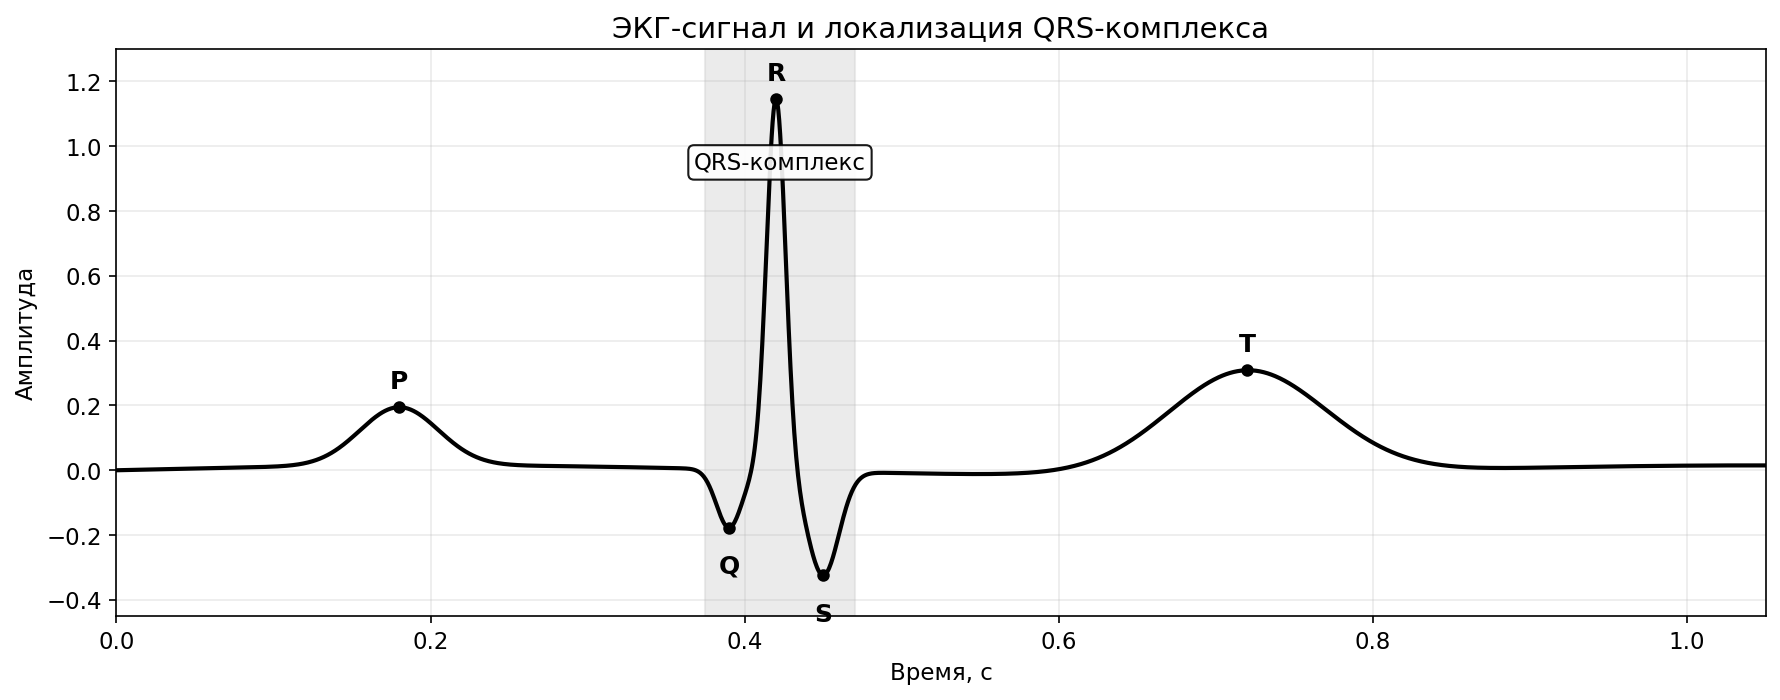

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Временная ось
t = np.linspace(0, 1.2, 2000)

# ЭКГ-сигнал
def gauss(x, mu, sigma, amp):
    return amp * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

ecg = (
    gauss(t, 0.18, 0.025, 0.18) +   # P
    gauss(t, 0.39, 0.008, -0.18) +  # Q
    gauss(t, 0.42, 0.006, 1.15) +   # R
    gauss(t, 0.45, 0.010, -0.32) +  # S
    gauss(t, 0.72, 0.050, 0.32)     # T
)

# Легкая базовая линия
ecg += 0.015 * np.sin(2 * np.pi * 1.2 * t)

plt.figure(figsize=(12, 4.8), dpi=150)
plt.plot(t, ecg, color='black', linewidth=2)

# Выделение зоны QRS-комплекса
qrs_start, qrs_end = 0.375, 0.47
plt.axvspan(qrs_start, qrs_end, color='lightgray', alpha=0.45, label='QRS-комплекс')

# Подписи характерных точек
points = {
    'P': 0.18,
    'Q': 0.39,
    'R': 0.42,
    'S': 0.45,
    'T': 0.72
}

for label, x0 in points.items():
    y0 = ecg[np.argmin(np.abs(t - x0))]
    plt.scatter(x0, y0, color='black', s=25, zorder=3)
    dy = 0.08 if label not in ['Q', 'S'] else -0.12
    plt.text(x0, y0 + dy, label, ha='center', va='center', fontsize=12, fontweight='bold')

# Подпись выделенной области
plt.text((qrs_start + qrs_end) / 2, 0.95, 'QRS-комплекс',
         ha='center', va='center', fontsize=11,
         bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='black', alpha=0.9))

plt.title('ЭКГ-сигнал и локализация QRS-комплекса', fontsize=14)
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.grid(alpha=0.25)
plt.xlim(0, 1.05)
plt.ylim(-0.45, 1.3)
plt.tight_layout()
plt.show()

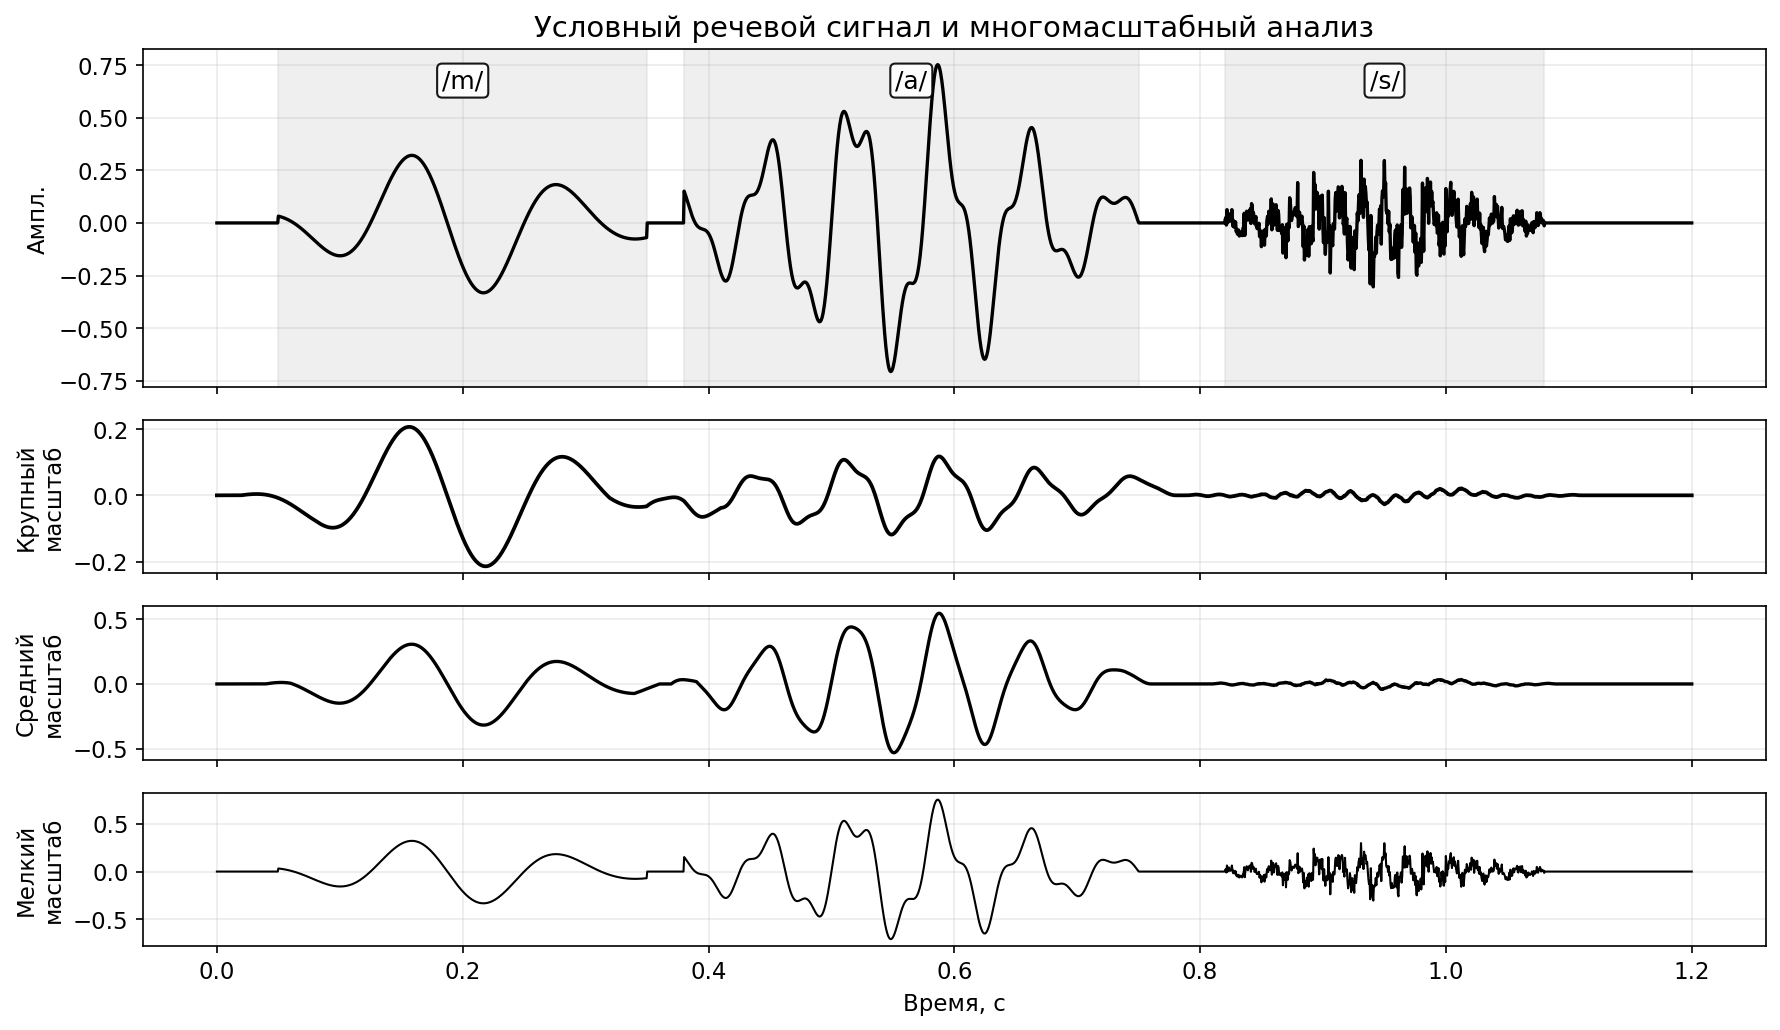

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(2)

# Временная ось
t = np.linspace(0, 1.2, 2400)

# Условный речевой сигнал из нескольких участков
signal = np.zeros_like(t)

# Участок 1: /m/ 
seg1 = (t >= 0.05) & (t < 0.35)
signal[seg1] = 0.35 * np.sin(2 * np.pi * 8 * t[seg1]) * (1 + 0.2 * np.sin(2 * np.pi * 2 * t[seg1]))

# Участок 2: /a/ 
seg2 = (t >= 0.38) & (t < 0.75)
signal[seg2] = (
    0.55 * np.sin(2 * np.pi * 14 * t[seg2]) +
    0.18 * np.sin(2 * np.pi * 38 * t[seg2])
)

# Участок 3: /s/
seg3 = (t >= 0.82) & (t < 1.08)
noise_like = np.random.randn(seg3.sum())
signal[seg3] = 0.18 * np.sin(2 * np.pi * 55 * t[seg3]) + 0.10 * noise_like

# Огибающая для более "речевого" вида
envelope = (
    0.9 * np.exp(-((t - 0.20) / 0.11) ** 2) +
    1.1 * np.exp(-((t - 0.56) / 0.14) ** 2) +
    0.8 * np.exp(-((t - 0.95) / 0.10) ** 2)
)
signal *= envelope

def moving_average(x, w):
    kernel = np.ones(w) / w
    return np.convolve(x, kernel, mode='same')

coarse = moving_average(signal, 121)   # крупный масштаб
medium = moving_average(signal, 41)    # средний масштаб
fine = signal                          # мелкий масштаб

fig, axes = plt.subplots(
    4, 1, figsize=(12, 7), sharex=True,
    gridspec_kw={"height_ratios": [2.2, 1, 1, 1]},
    dpi=150
)

# 1) Речевой сигнал
axes[0].plot(t, signal, color='black', linewidth=1.6)
axes[0].set_title("Условный речевой сигнал и многомасштабный анализ", fontsize=14)
axes[0].set_ylabel("Ампл.")
axes[0].grid(alpha=0.25)

# Подсветка фонемных участков
phonemes = [
    (0.05, 0.35, "/m/"),
    (0.38, 0.75, "/a/"),
    (0.82, 1.08, "/s/")
]

for start, end, label in phonemes:
    axes[0].axvspan(start, end, color='lightgray', alpha=0.35)
    axes[0].text((start + end) / 2, 0.9 * np.max(signal), label,
                 ha='center', va='center', fontsize=12,
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='black', alpha=0.9))

# 2) Крупный масштаб
axes[1].plot(t, coarse, color='black', linewidth=1.8)
axes[1].set_ylabel("Крупный\nмасштаб")
axes[1].grid(alpha=0.25)

# 3) Средний масштаб
axes[2].plot(t, medium, color='black', linewidth=1.6)
axes[2].set_ylabel("Средний\nмасштаб")
axes[2].grid(alpha=0.25)

# 4) Мелкий масштаб
axes[3].plot(t, fine, color='black', linewidth=1.0)
axes[3].set_ylabel("Мелкий\nмасштаб")
axes[3].set_xlabel("Время, с")
axes[3].grid(alpha=0.25)

plt.tight_layout()
plt.show()